# Predicting Term Deposit Subscription — Bank Marketing Dataset

**Machine Learning — Assignment 2**
M.Tech (AIML / DSE), BITS Pilani WILP

| | |
|---|---|
| **Name** | Het Patel |
| **BITS ID** | 2025AC05326 |
| **Dataset** | Bank Marketing (UCI ML Repository, ID 222) |
| **Task** | Binary classification |

---

### Problem statement

A Portuguese retail bank ran a series of direct marketing campaigns over the
phone. For every call we know who the client was, what their financial
situation looked like, and how the campaign had treated them so far. What we
want to know is whether the call ended with the client subscribing to a term
deposit.

Framed as an ML problem: given 16 client / campaign attributes, predict the
binary target `y` (`yes` = subscribed, `no` = did not). The business value is
straightforward — if the bank can rank clients by their likelihood of saying
yes, the same call-centre budget reaches more subscribers.

### Notebook roadmap

| Section | What happens |
|---|---|
| 1 | Load the data straight from UCI |
| 2 | Inspect structure, dtypes, class balance |
| 3 | Exploratory data analysis |
| 4 | Preprocessing design and train/test split |
| 5 | Train the six classifiers |
| 6 | Comparison table of all six metrics |
| 7 | Confusion matrices and ROC curves |
| 8 | Which features actually drive the prediction |
| 9 | Leakage check on `duration` |
| 10 | Export artifacts for the Streamlit app |
| 11 | Observations and conclusion |

---
## 0. Setup

In [1]:
# Standard scientific stack.
import io
import os
import zipfile
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# One seed reused everywhere, so the whole notebook reproduces end to end.
RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.2.2 | numpy 2.0.2


---
## 1. Loading the data

UCI ships this dataset as a zip containing four CSVs. We want `bank-full.csv`
— the complete 45,211-row version — and it is semicolon-delimited, which is
easy to miss and produces a single-column DataFrame if you forget `sep=";"`.

The download is cached to disk on first run. That matters here because the
assignment has to be executed on the BITS Virtual Lab, where outbound network
access is not always reliable; on a re-run the notebook reads the local copy
and never touches the network.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "bank-full.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Local copy not found — downloading from UCI...")
    response = requests.get(DATA_URL, timeout=60)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        # Write the CSV out so subsequent runs are offline-safe.
        with archive.open("bank-full.csv") as src, open(CSV_PATH, "wb") as dst:
            dst.write(src.read())
    print(f"Saved to {CSV_PATH}")
else:
    print(f"Using cached copy at {CSV_PATH}")

# Semicolon separator — this is a European-format CSV.
df = pd.read_csv(CSV_PATH, sep=";")

print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Local copy not found — downloading from UCI...
Saved to data/bank-full.csv

Shape: 45,211 rows x 17 columns


---
## 2. Data inspection

### Dataset description

45,211 phone contacts, 16 input features plus the target. Comfortably clears
the assignment minimums of 12 features and 500 instances.

**Client attributes** — `age`, `job`, `marital`, `education`, `default`
(credit in default), `balance` (average yearly balance in euros), `housing`
(housing loan), `loan` (personal loan)

**Current campaign** — `contact` (channel), `day`, `month`, `duration`
(call length in seconds), `campaign` (contacts made this campaign)

**Previous campaign** — `pdays` (days since last contact, `-1` = never),
`previous` (contacts before this campaign), `poutcome` (previous outcome)

**Target** — `y`: did the client subscribe to a term deposit?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
display(df.head())
display(df.describe().T)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [5]:
# Two things worth confirming before any modelling: whether anything is
# missing, and how lopsided the target is.
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing cells")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True).mul(100).round(2)
print(pd.concat([target_counts, target_pct], axis=1, keys=["count", "percent"]))

Missing values per column:
0 total missing cells

Duplicate rows: 0

Target distribution:
     count  percent
y                  
no   39922     88.3
yes   5289     11.7


Two findings that shape everything downstream:

**No missing values.** The dataset encodes unknowns as the literal string
`"unknown"` inside the categorical columns rather than as `NaN`. So there is
nothing to impute, but `"unknown"` will (correctly) become its own one-hot
category, which is the right treatment since "we don't know this client's job"
is itself informative.

**The target is heavily imbalanced**, roughly 88% *no* to 12% *yes*. This is
the single most important fact in the notebook. A model that predicts *no*
for every single client scores 88% accuracy while being completely useless.
That is exactly why the assignment asks for MCC and AUC alongside accuracy ,
those two are the ones that will actually separate the models.

---
## 3. Exploratory data analysis

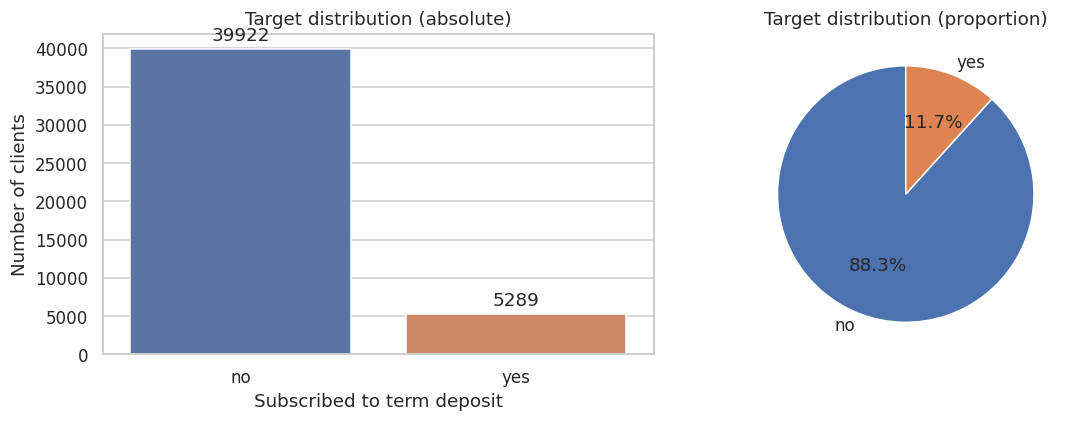

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x="y", hue="y", legend=False, ax=axes[0])
axes[0].set_title("Target distribution (absolute)")
axes[0].set_xlabel("Subscribed to term deposit")
axes[0].set_ylabel("Number of clients")

# Annotate the bars — the percentage split is the takeaway, not the raw height.
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=3)

df["y"].value_counts(normalize=True).plot.pie(
    autopct="%1.1f%%", startangle=90, ax=axes[1],
    colors=sns.color_palette("deep")[:2], ylabel=""
)
axes[1].set_title("Target distribution (proportion)")

plt.tight_layout()
plt.show()

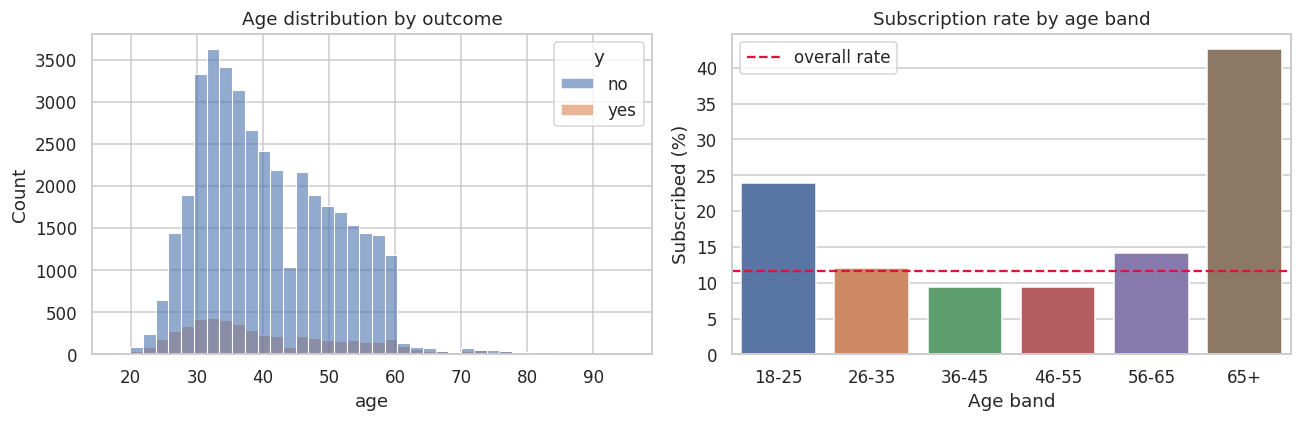

In [7]:
# Age is the most intuitive client attribute, so it is a good place to start.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="age", hue="y", bins=40, ax=axes[0],
             multiple="layer", alpha=0.6)
axes[0].set_title("Age distribution by outcome")


age_bands = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65, 100],
                   labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])
rate_by_age = df.assign(band=age_bands).groupby("band", observed=True)["y"].apply(
    lambda s: (s == "yes").mean() * 100
)

sns.barplot(x=rate_by_age.index, y=rate_by_age.values, ax=axes[1],
            hue=rate_by_age.index, legend=False)
axes[1].axhline((df["y"] == "yes").mean() * 100, ls="--", color="crimson",
                label="overall rate")
axes[1].set_title("Subscription rate by age band")
axes[1].set_ylabel("Subscribed (%)")
axes[1].set_xlabel("Age band")
axes[1].legend()

plt.tight_layout()
plt.show()

The raw histogram is dominated by the 30–40 bulge simply because that is where
most clients are. The rate plot on the right is the more useful view: the
relationship with age is **U-shaped**, not linear. Clients under 25 and over 65
subscribe at well above the base rate, while the 35–55 middle the bulk of
the customer base sits below it.

This is a concrete strike against Logistic Regression, which can only fit a
monotonic effect for `age` and will be forced to average the two ends of the U
into something close to flat. Tree-based models can split the range and capture
both tails.

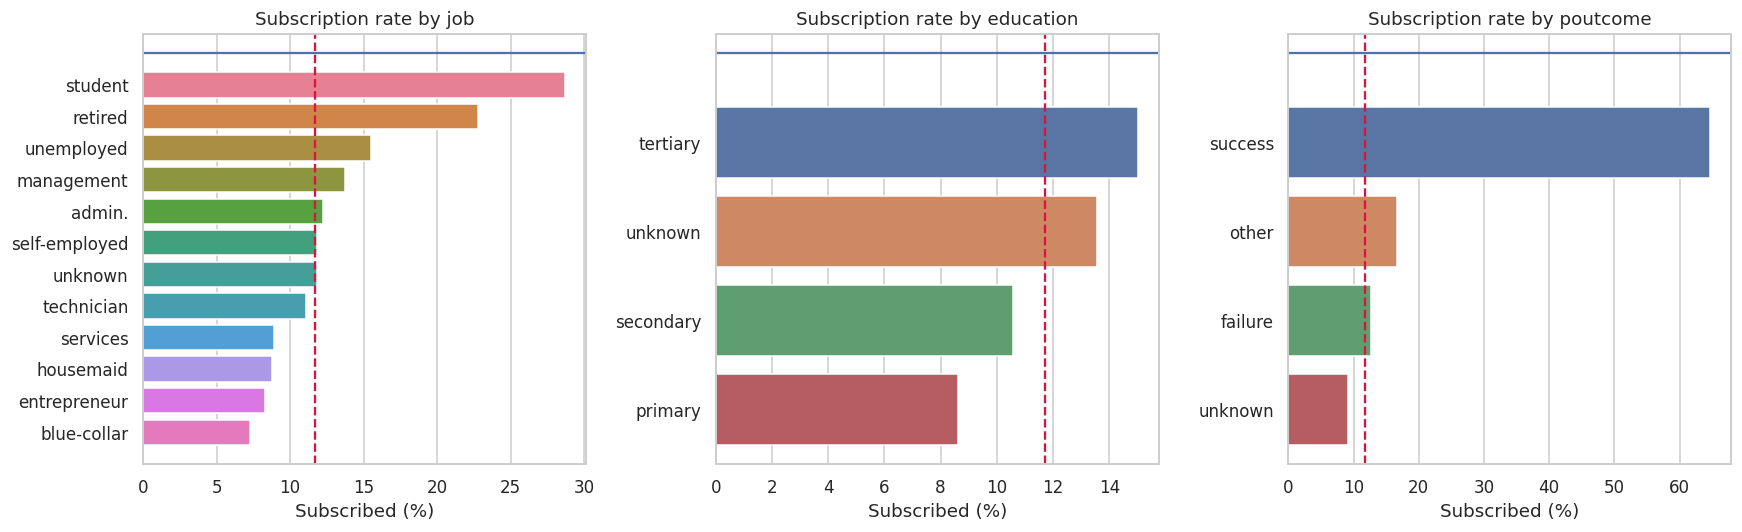

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["job", "education", "poutcome"]):
    rate = (
        df.groupby(col)["y"].apply(lambda s: (s == "yes").mean() * 100)
        .sort_values(ascending=False)
    )
    sns.barplot(x=rate.values, y=rate.index, ax=ax, hue=rate.index, legend=False)
    ax.axhline(-1)  # keeps the axis from clipping the top bar label
    ax.axvline((df["y"] == "yes").mean() * 100, ls="--", color="crimson")
    ax.set_title(f"Subscription rate by {col}")
    ax.set_xlabel("Subscribed (%)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

`poutcome` is doing a lot of work. Clients whose *previous* campaign ended in
success subscribe again at roughly 65% that is more than five times the base rate.
That single category is probably the strongest honest predictor in the dataset.

Among jobs, students and retirees stand out, which lines up neatly with the
U-shaped age effect seen above: they are the same two groups arriving from a
different direction.

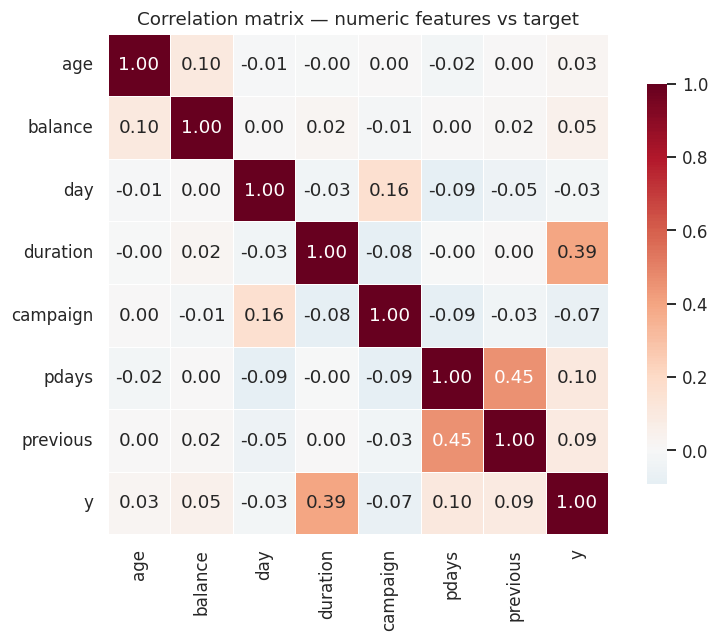

In [9]:
# Correlation matrix
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_frame = df[numeric_cols].assign(y=(df["y"] == "yes").astype(int))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_frame.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix — numeric features vs target")
plt.tight_layout()
plt.show()

Note how weak most of these correlations are. Nothing among the client
attributes exceeds about 0.1 against the target, which tells us the signal is
mostly non-linear or lives in the categorical columns, again favouring trees
over Logistic Regression.

The one exception is `duration` at roughly 0.39, far above everything else.
That number is a warning sign rather than good news, and section 9 deals with
why.

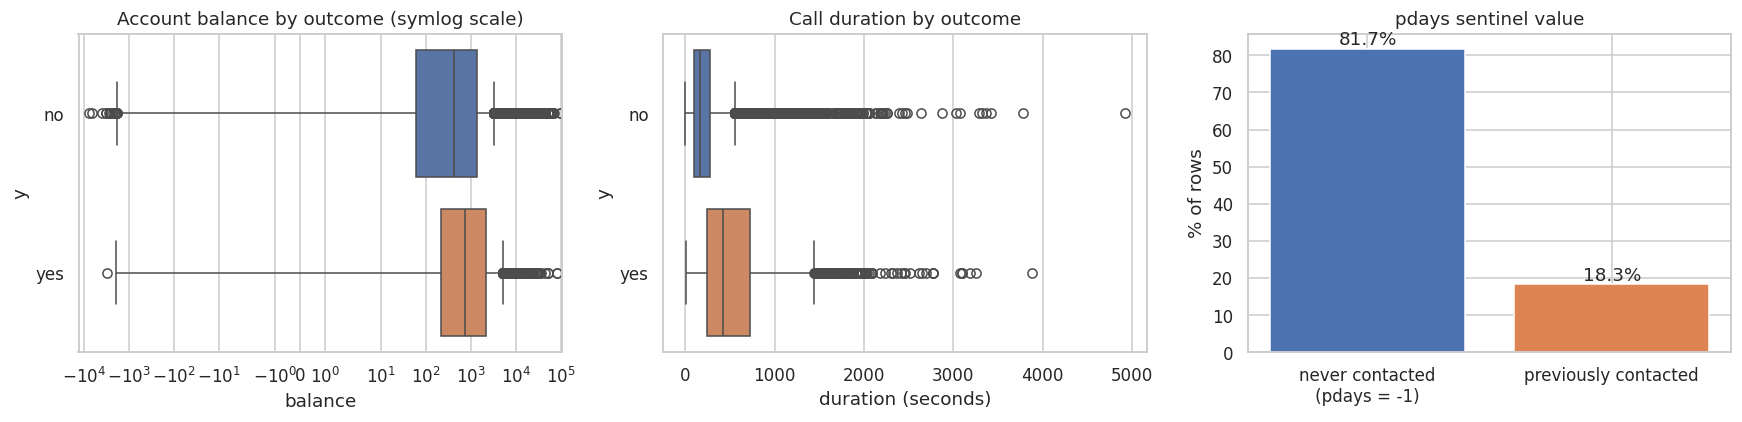

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="balance", y="y", hue="y", legend=False, ax=axes[0])
axes[0].set_xscale("symlog")
axes[0].set_title("Account balance by outcome (symlog scale)")

sns.boxplot(data=df, x="duration", y="y", hue="y", legend=False, ax=axes[1])
axes[1].set_title("Call duration by outcome")
axes[1].set_xlabel("duration (seconds)")

# pdays uses -1 as a sentinel for "never previously contacted". Showing how
# much of the column that sentinel occupies.
never_contacted = (df["pdays"] == -1).mean() * 100
axes[2].bar(["never contacted\n(pdays = -1)", "previously contacted"],
            [never_contacted, 100 - never_contacted],
            color=sns.color_palette("deep")[:2])
axes[2].set_ylabel("% of rows")
axes[2].set_title("pdays sentinel value")
axes[2].bar_label(axes[2].containers[0], fmt="%.1f%%")

plt.tight_layout()
plt.show()

Three things come out of this panel.

`balance` is extremely long-tailed , the median sits around €450 while the
maximum is over €102,000, and some balances are negative. The distributions for
the two classes overlap almost entirely, so on its own it separates the classes
poorly.

`duration` shows a dramatic separation. Calls ending in a subscription are
several times longer.

`pdays` is not really a continuous variable. About 82% of rows carry the
sentinel `-1` meaning "never contacted in a previous campaign", and the
remaining 18% carry a real day count. Feeding this to `StandardScaler` as-is
means the scaler computes a mean and standard deviation across a mixture of a
sentinel and a real measurement, which is not meaningful. We keep it as-is for
this assignment to stay comparable with the standard treatment of this
dataset, but it is flagged here as a known modelling compromise.

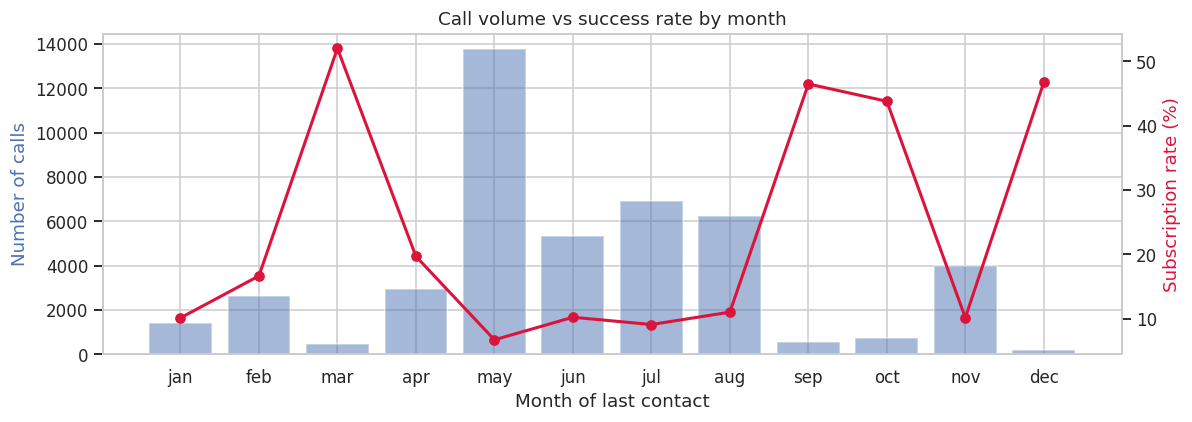

In [11]:
# Month has a strong seasonal pattern that is easy to miss because the raw
# volume and the success rate point in opposite directions.
month_order = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

monthly = (
    df.groupby("month")
      .agg(contacts=("y", "size"), rate=("y", lambda s: (s == "yes").mean() * 100))
      .reindex(month_order)
)

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(monthly.index, monthly["contacts"], alpha=0.5,
        color=sns.color_palette("deep")[0], label="calls made")
ax1.set_ylabel("Number of calls", color=sns.color_palette("deep")[0])
ax1.set_xlabel("Month of last contact")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["rate"], marker="o", lw=2,
         color="crimson", label="subscription rate")
ax2.set_ylabel("Subscription rate (%)", color="crimson")
ax2.grid(False)

plt.title("Call volume vs success rate by month")
fig.tight_layout()
plt.show()

This is the most counter-intuitive plot in the notebook. May is by far the
busiest month for the call centre and one of the *worst* performing. March,
September, October and December have tiny call volumes but subscription rates
three to five times the average.

Read as a business finding rather than a modelling one: the campaign was
spending its effort in the wrong months.

---
## 4. Preprocessing and train / test split

Design decisions here, and the reasoning behind each:

**Split before fitting anything.** The scaler and the encoder are fitted on
training rows only. Fitting them on the full dataset first would leak test-set
statistics into training and inflate every metric below.

**Stratified split**, because with a 12% positive class an unstratified split
can leave the test set with a noticeably different class balance by chance.

**One pipeline per model, not a shared pre-transformed matrix.** Wrapping the
`ColumnTransformer` and the estimator into a single `Pipeline` means one
`joblib` file per model contains everything needed to go from a raw CSV row to
a prediction. The Streamlit app then loads one object and calls `.predict()` on
raw uploaded data no risk of the app applying the transforms in a different
order or forgetting them entirely.

**`StandardScaler` on numeric, `OneHotEncoder` on categorical.** kNN needs the
scaling or `balance` (range ≈ 110,000) would drown out `age` (range ≈ 77) in
the distance calculation. `handle_unknown="ignore"` protects against a category
appearing in uploaded test data that was not present at training time.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = "y"

X = df.drop(columns=[TARGET])
y = df[TARGET].map({"no": 0, "yes": 1})   # 1 = subscribed, the positive class

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", numerical_features)
print("Categorical:", categorical_features)


def build_preprocessor(num_cols, cat_cols):
    """Return a fresh, unfitted ColumnTransformer for the given columns."""
    return ColumnTransformer(
        transformers=[
            ("numerical", StandardScaler(), num_cols),
            ("categorical",
             OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             cat_cols),
        ]
    )

Numerical  : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} rows | positive class {y_train.mean():.2%}")
print(f"Test : {X_test.shape[0]:,} rows | positive class {y_test.mean():.2%}")

# Quick check on what one-hot encoding does to the feature count.
probe = build_preprocessor(numerical_features, categorical_features)
probe.fit(X_train)
print(f"\nFeatures before encoding: {X_train.shape[1]}")
print(f"Features after encoding : {probe.transform(X_train.head()).shape[1]}")

Train: 36,168 rows | positive class 11.70%
Test : 9,043 rows | positive class 11.70%

Features before encoding: 16
Features after encoding : 51


---
## 5. Model training
Hyperparameter notes

| Model | Setting | Reason |
|---|---|---|
| Logistic Regression | `max_iter=1000` | the default 100 does not converge on 51 encoded features |
| Decision Tree | `max_depth=8`, `min_samples_leaf=50` | unrestricted, this tree grows to depth 40+ and memorises the training set |
| kNN | `n_neighbors=15` | with a 12% minority class, small *k* makes recall extremely unstable |
| Gaussian NB | defaults | no meaningful knobs; included as the assignment's probabilistic baseline |
| Random Forest | `n_estimators=200`, `min_samples_leaf=20` | see the file-size note below |
| Gradient Boosting | `n_estimators=200`, `lr=0.1` | standard starting point for this data size |

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score,
)

model_specs = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, random_state=RANDOM_STATE
    ),
    "kNN": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    # min_samples_leaf=20 keeps the serialised model under GitHub's 100 MB
    # file limit; see the markdown note above.
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=20,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=3, random_state=RANDOM_STATE
    ),
}


def evaluate(y_true, y_pred, y_prob):
    """The six metrics the assignment asks for, in the required order."""
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "AUC":       roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "MCC":       matthews_corrcoef(y_true, y_pred),
    }

In [15]:
import time

fitted_pipelines = {}
results = []

for name, estimator in model_specs.items():
    started = time.perf_counter()

    # Fresh preprocessor per model so no state is shared between them.
    pipeline = Pipeline([
        ("preprocessing", build_preprocessor(numerical_features,
                                             categorical_features)),
        ("classifier", estimator),
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    # AUC needs the probability of the positive class, not the hard label.
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    scores = evaluate(y_test, y_pred, y_prob)
    scores["ML Model Name"] = name
    results.append(scores)
    fitted_pipelines[name] = pipeline

    elapsed = time.perf_counter() - started
    print(f"{name:<22} done in {elapsed:6.1f}s  "
          f"(acc {scores['Accuracy']:.4f}, MCC {scores['MCC']:.4f})")

Logistic Regression    done in    0.8s  (acc 0.9012, MCC 0.4261)
Decision Tree          done in    0.5s  (acc 0.9014, MCC 0.4430)
kNN                    done in    5.1s  (acc 0.9012, MCC 0.4063)
Naive Bayes            done in    0.2s  (acc 0.8548, MCC 0.3774)
Random Forest          done in    8.7s  (acc 0.8998, MCC 0.3771)
Gradient Boosting      done in   33.4s  (acc 0.9092, MCC 0.4976)


---
## 6. Comparison table

This is the table reproduced in the README and the submitted PDF.

In [16]:
metric_cols = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]

results_df = (
    pd.DataFrame(results)[["ML Model Name"] + metric_cols]
    .round(4)
    .reset_index(drop=True)
)
display(
    results_df.style
    .highlight_max(subset=metric_cols, color="blue", axis=0)
    .format({c: "{:.4f}" for c in metric_cols})
    .set_caption("Test-set performance 9,043 held-out clients")
)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9012,0.9056,0.6445,0.3478,0.4518,0.4261
1,Decision Tree,0.9014,0.8832,0.6269,0.3875,0.4790,0.4430
2,kNN,0.9012,0.8824,0.6767,0.2987,0.4144,0.4063
3,Naive Bayes,0.8548,0.8101,0.4059,0.5198,0.4559,0.3774
4,Random Forest,0.8998,0.9272,0.7088,0.2439,0.3629,0.3771
5,Gradient Boosting,0.9092,0.9296,0.6695,0.4423,0.5327,0.4976


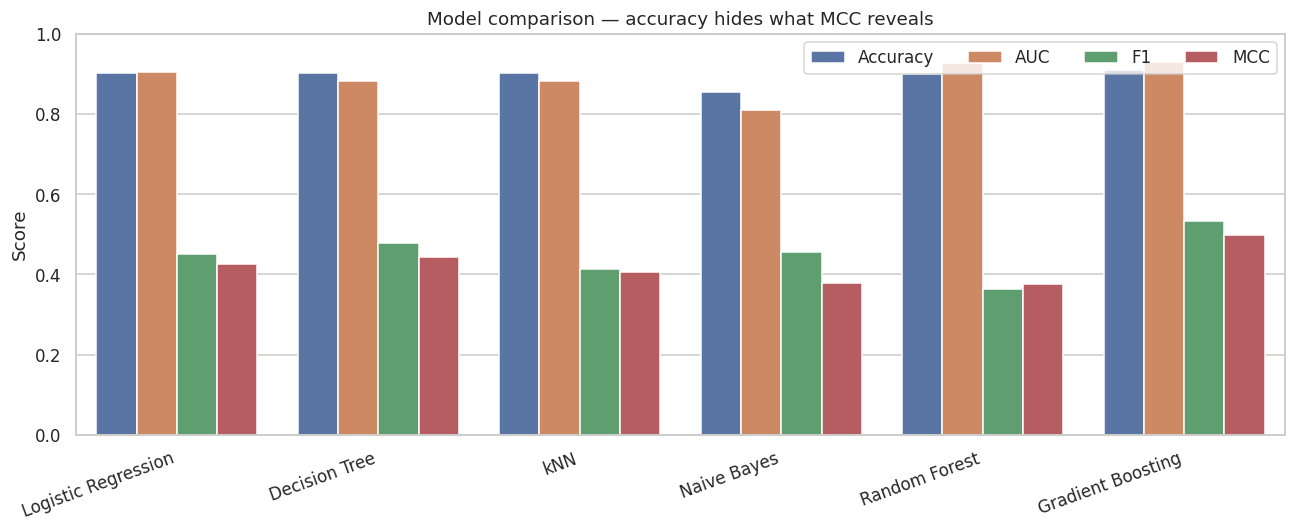

In [17]:
# The same numbers as a grouped bar chart. Accuracy is plotted alongside MCC
plot_frame = results_df.melt(
    id_vars="ML Model Name", value_vars=["Accuracy", "AUC", "F1", "MCC"],
    var_name="Metric", value_name="Score",
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=plot_frame, x="ML Model Name", y="Score", hue="Metric")
ax.set_title("Model comparison — accuracy hides what MCC reveals")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="", loc="upper right", ncol=4)
plt.tight_layout()
plt.show()

---
## 7. Confusion matrices and ROC curves

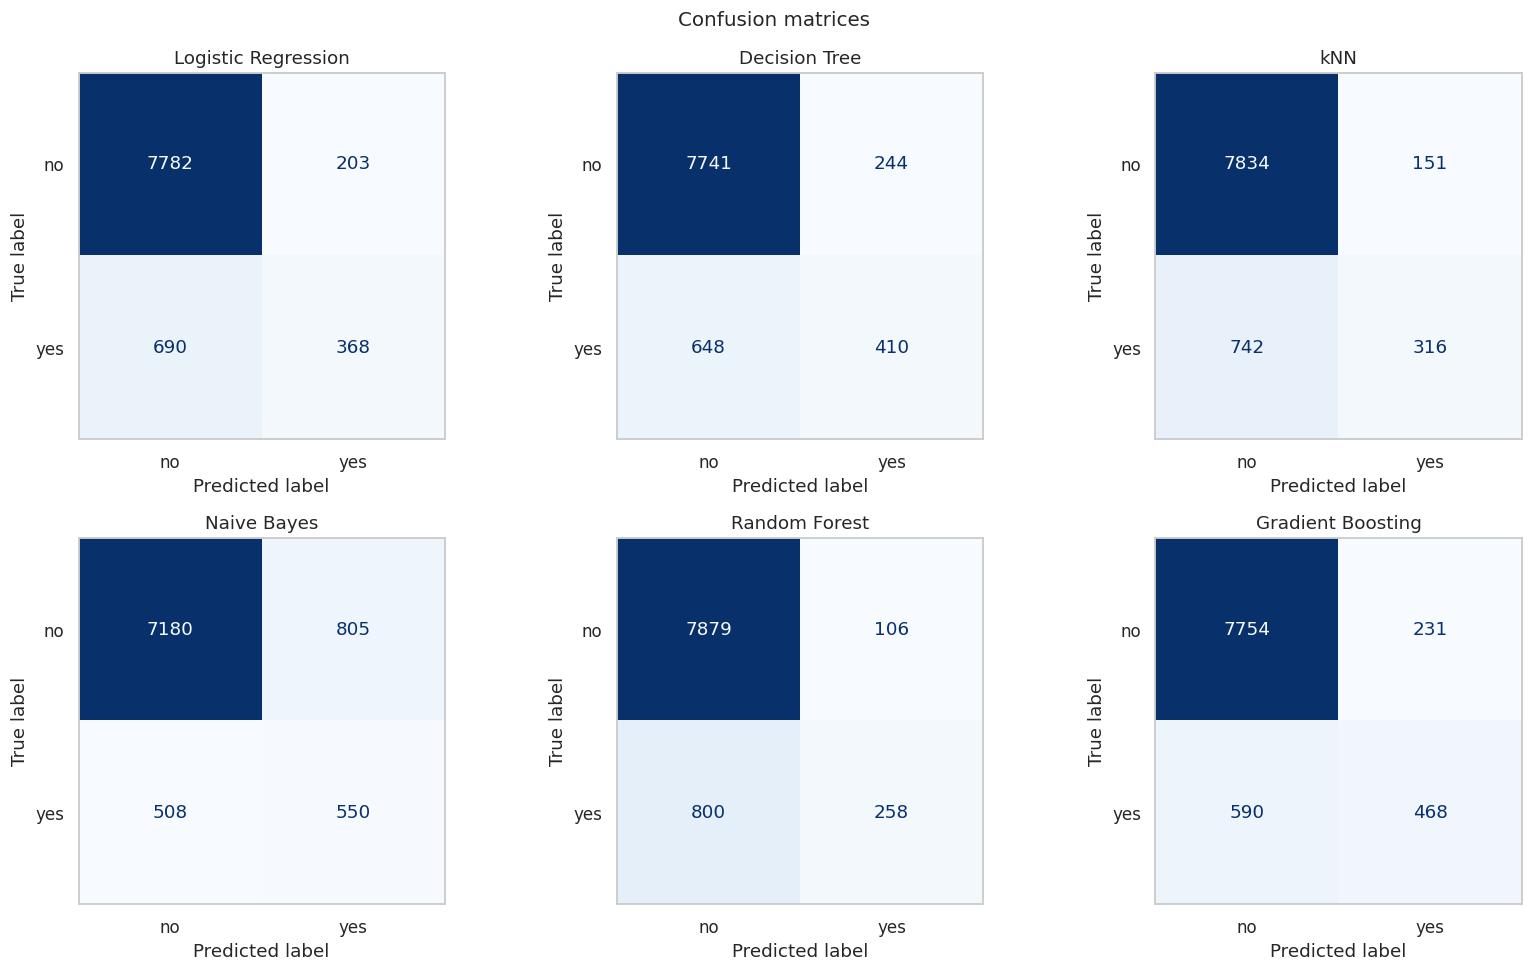

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, pipeline) in zip(axes.ravel(), fitted_pipelines.items()):
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["no", "yes"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(name)
    ax.grid(False)

fig.suptitle("Confusion matrices",
             fontsize=13)
plt.tight_layout()
plt.show()

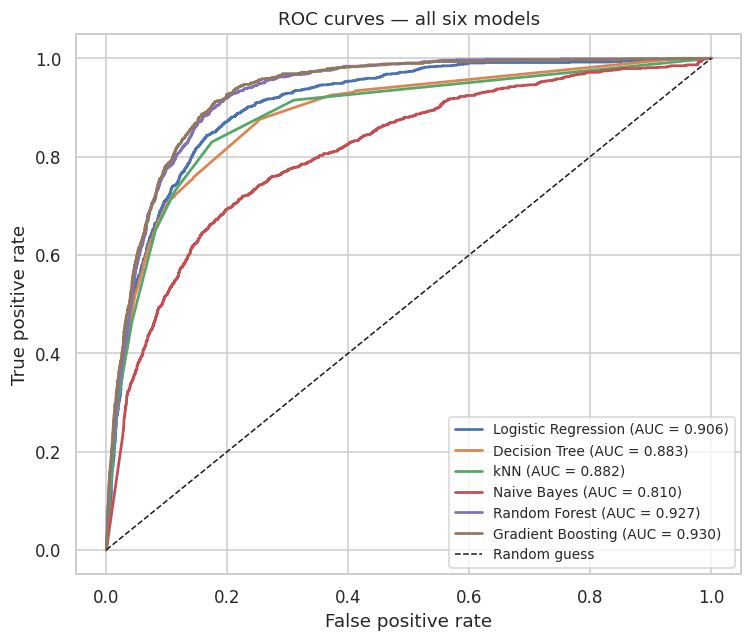

In [19]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, pipeline in fitted_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — all six models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
# The classification report for the best model by MCC, since that is the
# metric that respects the class imbalance.
from sklearn.metrics import classification_report

best_name = results_df.loc[results_df["MCC"].idxmax(), "ML Model Name"]
print(f"Best model by MCC: {best_name}\n")
print(classification_report(
    y_test, fitted_pipelines[best_name].predict(X_test),
    target_names=["no (0)", "yes (1)"], digits=4,
))

Best model by MCC: Gradient Boosting

              precision    recall  f1-score   support

      no (0)     0.9293    0.9711    0.9497      7985
     yes (1)     0.6695    0.4423    0.5327      1058

    accuracy                         0.9092      9043
   macro avg     0.7994    0.7067    0.7412      9043
weighted avg     0.8989    0.9092    0.9009      9043



---
## 8. Which features actually drive the prediction

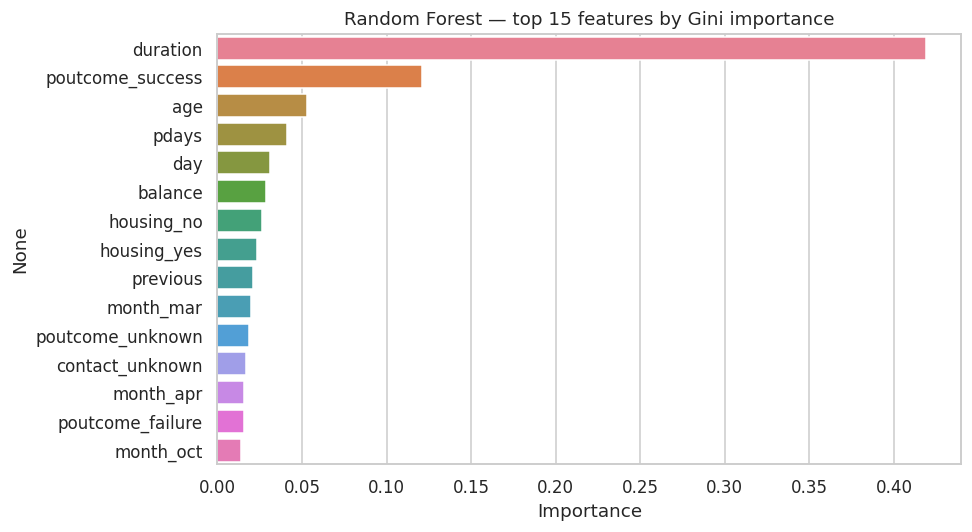

In [21]:
rf_pipeline = fitted_pipelines["Random Forest"]
encoded_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()

importances = (
    pd.Series(rf_pipeline.named_steps["classifier"].feature_importances_,
              index=encoded_names)
    .sort_values(ascending=False)
    .head(15)
)

# Strip the transformer prefixes ("numerical__", "categorical__") for display.
importances.index = importances.index.str.replace(
    r"^(numerical|categorical)__", "", regex=True
)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, legend=False)
plt.title("Random Forest — top 15 features by Gini importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

`duration` dominates, and by a wide margin. The next tier is `balance`, `age`,
`day` and `poutcome_success` which matches what the EDA suggested.

The dominance of `duration` is the reason for the next section.

---
## 9. Exporting artifacts for the Streamlit app

Each saved file is a complete `Pipeline`  preprocessing plus classifier. The
app loads one file and calls `.predict()` on the raw uploaded CSV, with no
transformation logic duplicated on the app side.

In [22]:
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

for name, pipeline in fitted_pipelines.items():
    filename = name.lower().replace(" ", "_") + ".joblib"
    path = os.path.join(MODEL_DIR, filename)

    # compress=3 is roughly a 3x saving on the tree ensembles and the kNN
    # pipeline (which carries the whole training set with it). Worth it for
    # both the GitHub push and the Streamlit Cloud cold start.
    joblib.dump(pipeline, path, compress=3)

    size_mb = os.path.getsize(path) / 1e6
    print(f"  {filename:<32} {size_mb:>7.1f} MB")

total_mb = sum(
    os.path.getsize(os.path.join(MODEL_DIR, f))
    for f in os.listdir(MODEL_DIR)
) / 1e6
print(f"\n  Total: {total_mb:.1f} MB (GitHub rejects any single file over 100 MB)")

# Metrics table travels with the models so the app can show the comparison
# without retraining anything.
results_df.to_csv(os.path.join(MODEL_DIR, "metrics.csv"), index=False)
print(f"\n  metrics.csv")

  logistic_regression.joblib           0.0 MB
  decision_tree.joblib                 0.0 MB
  knn.joblib                           1.6 MB
  naive_bayes.joblib                   0.0 MB
  random_forest.joblib                 4.9 MB
  gradient_boosting.joblib             0.1 MB

  Total: 6.5 MB (GitHub rejects any single file over 100 MB)

  metrics.csv


In [23]:
# Test data for the app: raw, unencoded features exactly as they appear in the
# source CSV, plus the target. The pipeline handles encoding at predict time.
test_data = X_test.copy()
test_data[TARGET] = y_test.values     # 0 / 1, matching training

test_data.to_csv("test_data.csv", index=False)
print(f"test_data.csv: {test_data.shape[0]:,} rows x {test_data.shape[1]} columns")
display(test_data.head(3))

test_data.csv: 9,043 rows x 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown,0
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown,0
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown,0


In [24]:
import sklearn

requirements = f"""streamlit>=1.37
scikit-learn=={sklearn.__version__}
pandas=={pd.__version__}
numpy=={np.__version__}
matplotlib=={plt.matplotlib.__version__}
seaborn=={sns.__version__}
joblib=={joblib.__version__}
"""

with open("requirements.txt", "w") as handle:
    handle.write(requirements)

print(requirements)

streamlit>=1.37
scikit-learn==1.6.1
pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
seaborn==0.13.2
joblib==1.5.3



In [25]:
# Bundle just the deliverables. Zipping the whole working directory would
import zipfile

with zipfile.ZipFile("project_files.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in sorted(os.listdir(MODEL_DIR)):
        bundle.write(os.path.join(MODEL_DIR, filename))
    bundle.write("test_data.csv")
    bundle.write("requirements.txt")

print(f"project_files.zip "
      f"({os.path.getsize('project_files.zip') / 1e6:.1f} MB)")

try:
    from google.colab import files
    files.download("project_files.zip")
except ImportError:
    print("Not running on Colab collect project_files.zip from the "
          "working directory manually.")

project_files.zip (6.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>